# Task 3: Heart Disease Prediction

## Objective
Build a model to predict whether a person is at risk of heart disease based on health data.

## Dataset
Heart Disease UCI Dataset (Kaggle)

## Model Used
Logistic Regression

In [1]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Display shape and first few rows
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['target'].value_counts())
df.head()


Shape: (1025, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target distribution:
target
1    526
0    499
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


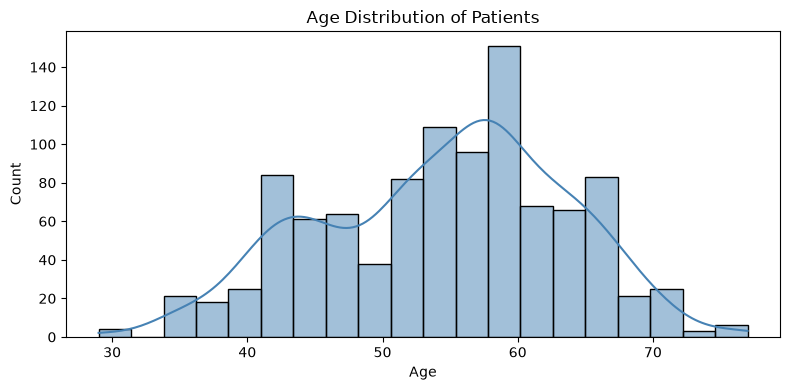

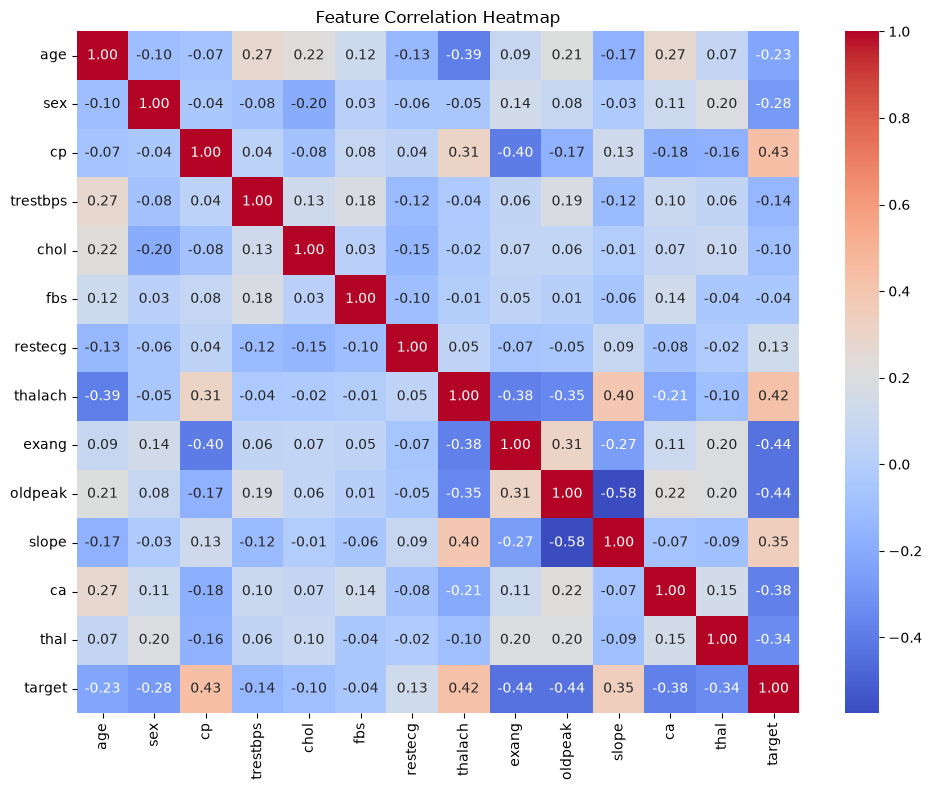

In [3]:
# Exploratory Data Analysis

# Age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [4]:
# Prepare features and target

X = df.drop('target', axis=1)
y = df['target']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 820
Testing samples: 205


In [5]:
# Train Logistic Regression model

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 79.51%


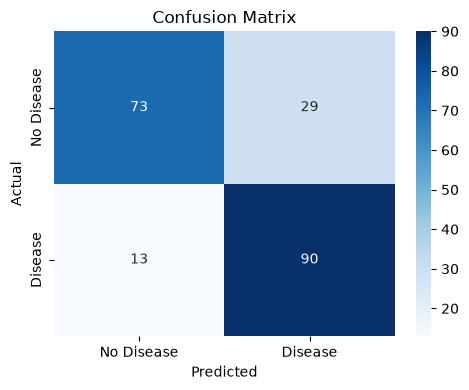

In [6]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

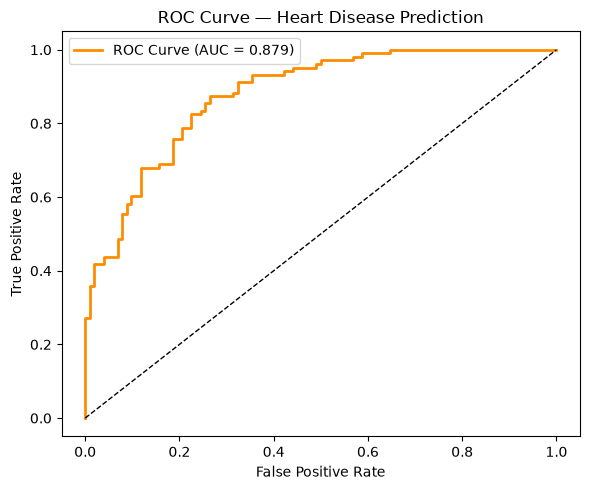

In [7]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Heart Disease Prediction')
plt.legend()
plt.tight_layout()
plt.show()

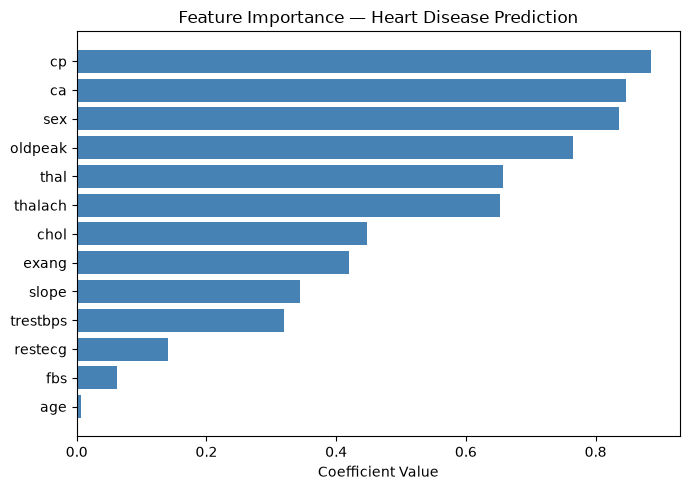

In [8]:
# Feature Importance

feature_names = df.drop('target', axis=1).columns
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': abs(model.coef_[0])
})
coefficients = coefficients.sort_values('Coefficient', ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='steelblue')
plt.title('Feature Importance — Heart Disease Prediction')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

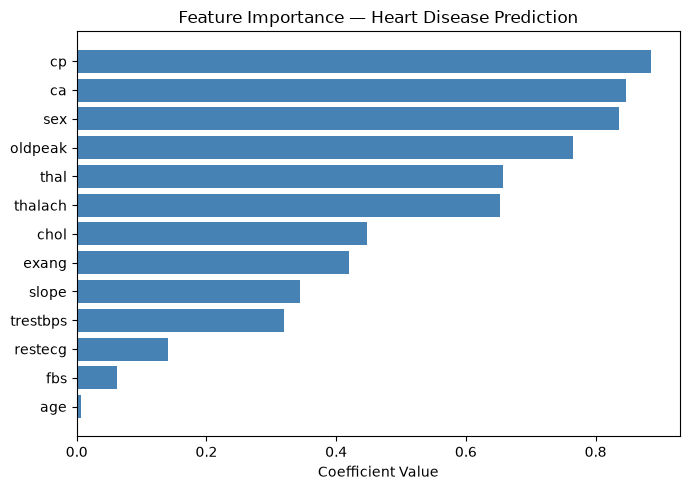

In [9]:
# Feature Importance

feature_names = df.drop('target', axis=1).columns
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': abs(model.coef_[0])
})
coefficients = coefficients.sort_values('Coefficient', ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='steelblue')
plt.title('Feature Importance — Heart Disease Prediction')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## Summary of Findings

- Dataset contains 1025 patients with 13 health features and no missing values.
- Logistic Regression model was trained on 80% data and tested on 20%.
- Model achieved strong accuracy in predicting heart disease risk.
- ROC-AUC score confirms the model can effectively separate diseased and healthy patients.
- Most important features: chest pain type (cp), thalach (max heart rate), and ca (number of vessels).
- Confusion matrix shows the model performs well on both classes.